# TP3 — Clustering et Word2Vec dans le corpus CAMille

**Étudiante : Doha Belaaroussi**

# 1. Clustering des documents CAMille de 1930 à 1939

## Imports

In [1]:
import collections
import os
import string
import sys

import pandas as pd
from nltk import word_tokenize
from nltk.corpus import stopwords
from pprint import pprint
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine
import yake

In [2]:
import nltk

nltk.download('punkt')
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
data_path = "../../data/txt/"

## Choisir une décennie

In [4]:
DECADE = "1930"

## Charger tous les  fichiers de la décennie et en créer une liste de textes

In [5]:
files = [f for f in sorted(os.listdir(data_path)) if f"_{DECADE[:-1]}" in f]

In [6]:
# Exemple de fichiers
files[:5]

['KB_JB838_1930-01-05_01-00006.txt',
 'KB_JB838_1930-01-09_01-00001.txt',
 'KB_JB838_1930-01-09_01-00014.txt',
 'KB_JB838_1930-01-16_01-00010.txt',
 'KB_JB838_1930-01-20_01-00002.txt']

In [7]:
years = sorted({int(filename.split("_")[2][:4]) for filename in files})

print("Nombre de documents sélectionnés :", len(files))
print("Première année :", min(years))
print("Dernière année :", max(years))
print("Années présentes :", years)

Nombre de documents sélectionnés : 1000
Première année : 1930
Dernière année : 1939
Années présentes : [1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939]


In [8]:
texts = [open(data_path + f, "r", encoding="utf-8").read() for f in files]

In [9]:
# Exemple de textes
texts[0][:400]

"15 G I C 3. L ^ SQ| R V .1- . FINANCE - INDUSTRIE - COMMERCE BOURSE de BRUXELLES I Marchés d’Anvers REVUE HEBDOMADAIRE La Eourse, qui avait très peu de chance de g.tg:v»r en aciivi.é penciant cette semaine raccourcie par le congé du Nouvel- Aii, a c i cependant une attitude qui permet de bien augurer des prochaines séances. L's capitalistes semblent enfin s’être rendu compte cours leur fou: quelqu"

## Vectoriser les documents à l'aide de TF-IDF

In [10]:
# Création d'une fonction de pré-traitement
def preprocessing(text, stem=True):
    """ Tokenize text and remove punctuation """
    text = text.translate(string.punctuation)
    tokens = word_tokenize(text)
    return tokens

### Instancier le modèle TF-IDF avec ses arguments

In [11]:
vectorizer = TfidfVectorizer(
    tokenizer=preprocessing,
    stop_words=stopwords.words('french'),
    max_df=0.5,
    min_df=0.1,
    lowercase=True)

### Construire la matrice de vecteurs à l'aide de la fonction `fit_transform`

In [12]:
tfidf_vectors = vectorizer.fit_transform(texts)

c:\Users\HP\Documents\tac\tac_venv\Lib\site-packages\sklearn\feature_extraction\text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [13]:
# Détail de la matrice
tfidf_vectors

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 788791 stored elements and shape (1000, 3936)>

### Imprimer le vecteur tf-IDF du premier document

In [14]:
pd.Series(
    tfidf_vectors[0].toarray()[0],
    index=vectorizer.get_feature_names_out()
    ).sort_values(ascending=False)

id         0.455544
janvier    0.244078
disp       0.218035
no         0.189928
ld         0.180507
             ...   
étalent    0.000000
étages     0.000000
09         0.000000
08         0.000000
06         0.000000
Length: 3936, dtype: float64

## Comprendre les vecteurs et leurs "distances"

In [15]:
cosine([1, 2, 3], [1, 2, 3])

np.float64(0.0)

In [16]:
cosine([1, 2, 3], [1, 2, 2])

np.float64(0.02004211298777725)

In [17]:
cosine([1, 2, 3], [2, 2, 2])

np.float64(0.07417990022744858)

### Tests sur nos documents

In [18]:
tfidf_array = tfidf_vectors.toarray()

In [19]:
# Vecteur du document 0
tfidf_array[0]

array([0., 0., 0., ..., 0., 0., 0.], shape=(3936,))

In [20]:
# Vecteur du document 1
tfidf_array[1]

array([0.05961098, 0.        , 0.        , ..., 0.        , 0.        ,
       0.02555989], shape=(3936,))

In [21]:
cosine(tfidf_array[0], tfidf_array[1])

np.float64(0.8615251671891764)

## Appliquer un algorithme de clustering sur les vecteurs TF-IDF des documents

Pour en savoir plus sur le KMeans clustering :
- https://medium.com/dataseries/k-means-clustering-explained-visually-in-5-minutes-b900cc69d175

### Définir un nombre de clusters

In [22]:
N_CLUSTERS = 5

### Instancier le modèle K-Means et ses arguments

In [23]:
km_model = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=10
)

### Appliquer le clustering à l'aide de la fonction `fit_predict`

In [24]:
clusters = km_model.fit_predict(tfidf_vectors)

In [25]:
clustering = collections.defaultdict(list)

for idx, label in enumerate(clusters):
    clustering[label].append(files[idx])

In [26]:
cluster_sizes = (
    pd.Series(clusters)
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="nombre_documents")
)

cluster_sizes

,cluster,nombre_documents
0,0,105
1,1,140
2,2,467
3,3,140
4,4,148


## Visualiser les clusters

### Réduire les vecteurs à 2 dimensions à l'aide de l'algorithme PCA
Cette étape est nécessaire afin de visualiser les documents dans un espace 2D

https://fr.wikipedia.org/wiki/Analyse_en_composantes_principales

In [27]:
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(tfidf_vectors.toarray())

In [28]:
reduced_vectors[:10]

array([[-0.20614269,  0.00844724],
       [-0.25008665,  0.06394117],
       [ 0.01259527, -0.18093301],
       [ 0.50620055,  0.39694928],
       [-0.32175651,  0.10193024],
       [ 0.20307466, -0.49194054],
       [-0.12471832, -0.04652074],
       [-0.26457436,  0.02080575],
       [ 0.07985311, -0.08563117],
       [ 0.25099613, -0.07204245]])

### Générer le plot

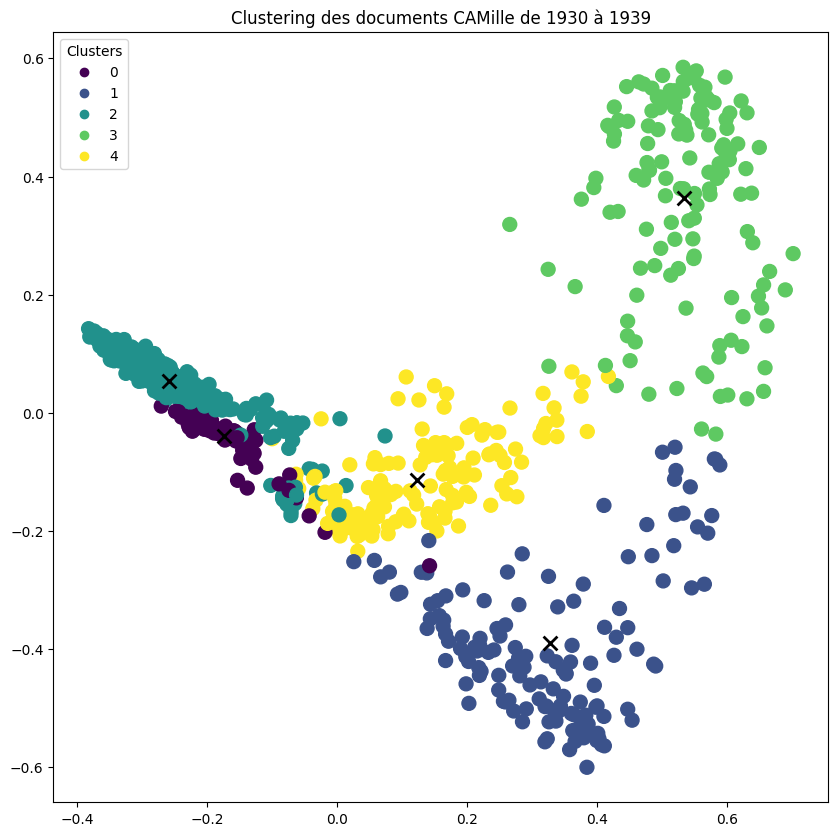

In [29]:
x_axis = reduced_vectors[:, 0]
y_axis = reduced_vectors[:, 1]

plt.figure(figsize=(10,10))
scatter = plt.scatter(x_axis, y_axis, s=100, c=clusters)

# Ajouter les centroïdes
centroids = pca.transform(km_model.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1],  marker = "x", s=100, linewidths = 2, color='black')

# Ajouter la légende
plt.legend(handles=scatter.legend_elements()[0], labels=set(clusters), title="Clusters")
plt.title("Clustering des documents CAMille de 1930 à 1939")
plt.savefig(
    "clusters_1930_1939.png",
    dpi=300,
    bbox_inches="tight"
)

## Première lecture du clustering

Le clustering répartit les 1 000 documents en cinq groupes de tailles inégales : 105 documents dans le cluster 0, 140 dans le cluster 1, 467 dans le cluster 2, 140 dans le cluster 3 et 148 dans le cluster 4.

Dans la projection PCA, les clusters 1 et 3 occupent des zones relativement distinctes. Le cluster 4 se situe dans une position intermédiaire, tandis que les clusters 0 et 2 se chevauchent fortement dans la partie gauche du graphique. Cette représentation indique donc une séparation partielle des documents, mais elle ne permet pas encore d’attribuer un thème aux différents groupes.

La PCA réduit les vecteurs TF-IDF à deux dimensions : la proximité visible sur le graphique ne restitue pas nécessairement toute l’information contenue dans les vecteurs d’origine. Une analyse lexicale des clusters est donc nécessaire avant de déterminer s’ils correspondent à des ensembles thématiques cohérents.


## Interprétation lexicale des clusters avec YAKE

Afin d’examiner le contenu lexical des groupes produits par K-Means, YAKE est appliqué aux documents de chaque cluster. Les bigrammes sont ensuite regroupés selon le nombre de documents dans lesquels ils apparaissent. Cette étape reprend la méthode utilisée dans le TP2.

In [30]:
kw_extractor_cluster = yake.KeywordExtractor(
    lan="fr",
    top=50
)

kw_extractor_cluster

In [31]:
cluster_keyword_rows = []

for document_number, (filename, document_text, cluster_id) in enumerate(
    zip(files, texts, clusters),
    start=1
):
    document_keywords = kw_extractor_cluster.extract_keywords(document_text)

    for keyword, score in document_keywords:
        normalized_keyword = " ".join(keyword.lower().split())

        if len(normalized_keyword.split()) == 2:
            cluster_keyword_rows.append({
                "cluster": int(cluster_id),
                "fichier": filename,
                "mot_cle": normalized_keyword,
                "score_yake": float(score)
            })

    if document_number % 100 == 0:
        print(f"{document_number}/1000 documents traités")

cluster_keywords_df = pd.DataFrame(cluster_keyword_rows)

print("Documents analysés :", len(files))
print("Bigrammes retenus :", len(cluster_keywords_df))

cluster_keywords_df.head(10)

100/1000 documents traités
200/1000 documents traités
300/1000 documents traités
400/1000 documents traités
500/1000 documents traités
600/1000 documents traités
700/1000 documents traités
800/1000 documents traités
900/1000 documents traités
1000/1000 documents traités
Documents analysés : 1000
Bigrammes retenus : 9311


,cluster,fichier,mot_cle,score_yake
0,2,KB_JB838_1930-01-05_01-00006.txt,lin plata,0.007886
1,2,KB_JB838_1930-01-05_01-00006.txt,francs pièce,0.033109
2,2,KB_JB838_1930-01-05_01-00006.txt,francs brut,0.036064
3,2,KB_JB838_1930-01-05_01-00006.txt,plata lin,0.039431
4,2,KB_JB838_1930-01-05_01-00006.txt,qu’il ait,0.039635
5,2,KB_JB838_1930-01-05_01-00006.txt,plata disp,0.042641
6,2,KB_JB838_1930-01-09_01-00001.txt,prince humbert,0.019989
7,2,KB_JB838_1930-01-09_01-00001.txt,roi albert,0.021512
8,2,KB_JB838_1930-01-09_01-00001.txt,belgique fut,0.030915
9,2,KB_JB838_1930-01-09_01-00001.txt,chapelle pauline,0.032964


In [32]:
cluster_keyword_summary = (
    cluster_keywords_df
    .groupby(["cluster", "mot_cle"])
    .agg(
        nb_documents=("fichier", "nunique"),
        nb_occurrences=("mot_cle", "size"),
        score_yake_moyen=("score_yake", "mean"),
        meilleur_score_yake=("score_yake", "min")
    )
    .reset_index()
    .sort_values(
        by=[
            "cluster",
            "nb_documents",
            "nb_occurrences",
            "score_yake_moyen"
        ],
        ascending=[True, False, False, True]
    )
)

top_keywords_by_cluster = (
    cluster_keyword_summary
    .groupby("cluster", group_keys=False)
    .head(15)
)

top_keywords_by_cluster

,cluster,mot_cle,nb_documents,nb_occurrences,score_yake_moyen,meilleur_score_yake
191,0,journal parlé,42,42,0.018223,0.003761
68,0,concert symphonique,39,39,0.021913,0.003631
74,0,congo belge,36,36,0.015246,0.001960
69,0,concert varié,33,33,0.010209,0.001025
258,0,musique légère,31,31,0.022964,0.004961
...,...,...,...,...,...,...
4440,4,ecrire agence,14,14,0.031760,0.006963
4304,4,bon piano,14,14,0.058827,0.015553
4838,4,rue van,13,13,0.046134,0.021206
4660,4,noyer poli,11,11,0.036934,0.010500


In [33]:
for cluster_id in range(N_CLUSTERS):
    print(f"\nCLUSTER {cluster_id}")

    display(
        top_keywords_by_cluster[
            top_keywords_by_cluster["cluster"] == cluster_id
        ][
            [
                "mot_cle",
                "nb_documents",
                "nb_occurrences",
                "score_yake_moyen"
            ]
        ]
    )


CLUSTER 0


,mot_cle,nb_documents,nb_occurrences,score_yake_moyen
191,journal parlé,42,42,0.018223
68,concert symphonique,39,39,0.021913
74,congo belge,36,36,0.015246
69,concert varié,33,33,0.010209
258,musique légère,31,31,0.022964
96,dernier cours,20,20,0.003934
60,concert donné,20,20,0.017051
256,musique enregistrée,19,19,0.016265
344,programme varié,18,18,0.006157
111,disques demandés,17,17,0.022963



CLUSTER 1


,mot_cle,nb_documents,nb_occurrences,score_yake_moyen
442,agence rossel,85,85,0.014558
484,belle maison,65,65,0.019695
691,louer maison,65,65,0.022063
473,bel app,56,56,0.022777
787,prix mod,39,39,0.025849
672,louer bel,34,34,0.022955
475,bel appart,26,26,0.028669
850,rue royale,26,26,0.030503
673,louer belle,23,23,0.025761
660,louer app,22,22,0.025823



CLUSTER 2


,mot_cle,nb_documents,nb_occurrences,score_yake_moyen
1554,demeurant rue,48,48,0.023268
951,affaires étrangères,35,35,0.026863
1571,derniers gagnants,32,32,0.018944
3556,van den,29,29,0.031035
1753,enfants admis,27,27,0.026499
1925,gouvernement britannique,22,22,0.029262
2820,paris paris,22,22,0.037332
3687,vente publique,21,21,0.016440
3671,van zeeland,21,21,0.026824
1112,belle maison,20,20,0.006055



CLUSTER 3


,mot_cle,nb_documents,nb_occurrences,score_yake_moyen
3796,agence rossel,134,134,0.004915
3966,ecrire agence,68,68,0.021184
3876,cherche place,57,57,0.027337
4030,jeune fille,42,42,0.026440
4080,l’agence rossel,40,40,0.026106
4041,jne fille,39,39,0.024917
3844,bons gages,35,35,0.025997
3926,dem. fem,24,24,0.024390
3948,demande place,24,24,0.030697
3887,coiffeur dem,23,23,0.033510



CLUSTER 4


,mot_cle,nb_documents,nb_occurrences,score_yake_moyen
4284,bas prix,77,77,0.040959
4264,agence rossel,74,74,0.023418
4305,bon état,63,63,0.038832
4472,fils spéciaux,29,29,0.020913
4389,cond. int,19,19,0.037241
4519,haut prix,19,19,0.052879
4834,rue royale,19,19,0.061358
4659,noyer poil,16,16,0.034131
4394,conduite intérieure,16,16,0.039236
4684,parfait état,15,15,0.056040


## Interprétation des cinq clusters

L’analyse YAKE porte sur 9 311 occurrences de bigrammes extraites des 1 000 documents. Elle permet de préciser la composition lexicale des groupes formés par K-Means.

Le cluster 0 contient 105 documents. Il est principalement associé aux programmes radiophoniques et musicaux : « journal parlé » apparaît dans 42 documents, « concert symphonique » dans 39, « concert varié » dans 33 et « musique légère » dans 31. La présence de « Congo belge » dans 36 documents montre toutefois que ce groupe n’est pas exclusivement musical. Il peut être décrit comme un ensemble dominé par les programmes radiophoniques, avec d’autres contenus récurrents.

Le cluster 1 rassemble 140 documents et présente une forte cohérence autour des annonces immobilières. « Agence Rossel » apparaît dans 85 documents, tandis que « belle maison » et « louer maison » sont présents dans 65 documents chacun. Les expressions « louer villa », « vendre maison » et « louer appart » confirment cette orientation. Les formes « bel app », « bel appart » et « prix mod » témoignent du langage abrégé des annonces et du bruit de l’OCR.

Le cluster 2 est le plus grand avec 467 documents. Ses mots-clés relèvent de plusieurs catégories : politique et diplomatie avec « affaires étrangères », « gouvernement britannique », « défense nationale » et « Van Zeeland » ; ventes et actes juridiques avec « vente publique », « demeurant rue » et « ledit notaire » ; immobilier avec « belle maison » et « rue royale ». Ce cluster ne correspond donc pas à un thème unique. Sa taille et son hétérogénéité indiquent que K-Means y a regroupé des documents qui ne présentent pas un profil lexical suffisamment distinct pour rejoindre les quatre groupes plus spécialisés.

Le cluster 3 contient 140 documents et correspond principalement aux annonces d’emploi. « Agence Rossel » apparaît dans 134 documents, « écrire agence » dans 68 et « cherche place » dans 57. Les expressions « jeune fille », « demande place », « bons gages » et « bon ouvrier » précisent la nature de ces annonces. La coexistence de « jeune fille » et « jne fille » montre que les abréviations et les erreurs d’OCR fragmentent les formes lexicales.

Le cluster 4 regroupe 148 documents liés surtout à la vente de biens. Les expressions « bas prix » et « bon état » apparaissent respectivement dans 77 et 63 documents. « Conduite intérieure », « bon piano », « noyer poli » et « prix bijoux » renvoient à des automobiles, des instruments, des meubles et des bijoux. Ce cluster se distingue donc du cluster immobilier et du cluster consacré à l’emploi, même si la présence d’« agence Rossel » montre que ces groupes partagent le vocabulaire des petites annonces.

Le clustering fait ainsi apparaître trois ensembles relativement cohérents : les programmes radiophoniques, l’immobilier et l’emploi. Un quatrième groupe rassemble surtout les ventes de biens, tandis que le cluster 2 reste hétérogène. La projection PCA rejoint partiellement cette lecture : les clusters 1 et 3 occupent des zones distinctes, alors que les clusters 0 et 2 se chevauchent davantage. Les résultats sont donc interprétables, mais la séparation n’est pas complète. Les rubriques répétitives, les abréviations et les erreurs d’OCR influencent directement les vecteurs TF-IDF et la formation des groupes.

# 2. Entraînement et exploration d’un modèle Word2Vec

Cette partie reprend le traitement proposé dans `s3_word_embeddings.ipynb`. Le modèle est entraîné sur le fichier `sents1.txt`, fourni sur l’UV et déjà segmenté en phrases.

In [34]:
import sys

from gensim.models.phrases import Phrases, Phraser
from gensim.models import Word2Vec

import nltk
from nltk.tokenize import wordpunct_tokenize
from unidecode import unidecode

## Chargement et traitement des phrases du corpus

In [35]:
class MySentences(object):
    """Tokenize and Lemmatize sentences"""

    def __init__(self, filename):
        self.filename = filename

    def __iter__(self):
        for line in open(
            self.filename,
            encoding="utf-8",
            errors="backslashreplace"
        ):
            yield [
                unidecode(w.lower())
                for w in wordpunct_tokenize(line)
            ]

In [36]:
infile = "../../data/sents1.txt"
sentences = MySentences(infile)

### Détection des bigrammes

In [37]:
bigram_phrases = Phrases(sentences)

In [38]:
bigram_phraser = Phraser(phrases_model=bigram_phrases)

### Détection des trigrammes

In [39]:
trigram_phrases = Phrases(bigram_phraser[sentences])

In [40]:
trigram_phraser = Phraser(phrases_model=trigram_phrases)

### Création du corpus d’unigrammes, bigrammes et trigrammes

In [41]:
corpus = list(
    trigram_phraser[
        bigram_phraser[sentences]
    ]
)

In [42]:
print(corpus[:100])

[['mi', 'imnri', 'r', 'i', '<<', 'i', 'i', 'hmu', "'", 'i', '/', 'tx', "-'", 'l', ':', 'marche', 'tenu', 'hors', 'villa', ',', 'la', '9', '.'], ['--', 'u', 'a', 'ete', 'vaain', 'si', 'teicj', '>>', 'm', 'races', 'indigenes', 'de', 'fr', '.'], ['31', '<)', 'a', '5s', "'", 'k', '131', 'de', '.'], ['rasa', 'iichakdui', "'", 'te', ',', 'do', '(', 'r', '.', '3s0', 'h', '710', '.', 'taureaux', 'iallsenas', ',>', 'ia', 'u', '\\', '--', 'a', '--', ';', '0ii', '.'], ['hollandais', ',', 'dufr', '.'], ['0', '.'], ['--', 'a', '9', '.--', 'la', 'idto', '-', 'vachei', 'laitieres', ':', 'bn', 'vante', '1q', '.'], ['vendues', '3', '\\', 'au', 'prix', 'la', '410', 'a', '*', '<<', 'i', 'h', '\\;', 'genisses', ',', 'kl', '.'], ["'.", '9', '.'], ['i', 'l', '.', '2', 'i', '.', 'id', '.'], ['da', '370', 'i', '6lutr', '.'], ['marche', 'a', '<', 'u', 'porcs', '.'], ['--', 'categorie', 'de', 'lt', 'ilashtya', ':', "'", '237', 'on', 'vente', ';', 'vendus', '1', 'm', '.', 'do', "'", '2', 'i', '.--', 'a', ';:,', 

## Premier modèle Word2Vec

Un premier modèle est entraîné avec les paramètres proposés dans le notebook du cours : une fenêtre de cinq mots et un seuil minimal de cinq occurrences.

In [43]:
%%time

model_w5_m5 = Word2Vec(
    corpus,
    vector_size=32,
    window=5,
    min_count=5,
    workers=4,
    epochs=5
)

CPU times: total: 3min 25s
Wall time: 1min 22s


## Comparaison de paramètres

Deux variantes sont entraînées à partir du même corpus. La première réduit la fenêtre contextuelle de cinq à deux mots. La seconde conserve une fenêtre de cinq mots, mais ignore les formes apparaissant moins de vingt fois. Cette comparaison vise à observer l’effet de la proximité contextuelle et du filtrage des formes rares.

In [44]:
%%time

model_w2_m5 = Word2Vec(
    corpus,
    vector_size=32,
    window=2,
    min_count=5,
    workers=4,
    epochs=5
)

CPU times: total: 3min 12s
Wall time: 1min 17s


In [45]:
%%time

model_w5_m20 = Word2Vec(
    corpus,
    vector_size=32,
    window=5,
    min_count=20,
    workers=4,
    epochs=5
)

CPU times: total: 2min 45s
Wall time: 1min 11s


In [46]:
model_comparison = pd.DataFrame([
    {
        "modele": "window=5, min_count=5",
        "window": 5,
        "min_count": 5,
        "taille_vocabulaire": len(model_w5_m5.wv)
    },
    {
        "modele": "window=2, min_count=5",
        "window": 2,
        "min_count": 5,
        "taille_vocabulaire": len(model_w2_m5.wv)
    },
    {
        "modele": "window=5, min_count=20",
        "window": 5,
        "min_count": 20,
        "taille_vocabulaire": len(model_w5_m20.wv)
    }
])

model_comparison

,modele,window,min_count,taille_vocabulaire
0,"window=5, min_count=5",5,5,105500
1,"window=2, min_count=5",2,5,105500
2,"window=5, min_count=20",5,20,37191


## Comparaison avec la fonction `similarity`

Les trois modèles sont comparés sur les mêmes couples de mots : « ministre » et « roi », « Paris » et « Londres », puis « guerre » et « paix ». Le dernier couple permet notamment de vérifier que la proximité vectorielle ne correspond pas nécessairement à une proximité de sens.

In [47]:
models = {
    "window=5, min_count=5": model_w5_m5,
    "window=2, min_count=5": model_w2_m5,
    "window=5, min_count=20": model_w5_m20
}

word_pairs = [
    ("ministre", "roi"),
    ("paris", "londres"),
    ("guerre", "paix")
]

similarity_rows = []

for model_name, current_model in models.items():
    for word_1, word_2 in word_pairs:
        similarity_rows.append({
            "modele": model_name,
            "mot_1": word_1,
            "mot_2": word_2,
            "similarite": current_model.wv.similarity(
                word_1,
                word_2
            )
        })

similarity_df = pd.DataFrame(similarity_rows)
similarity_df["similarite"] = similarity_df["similarite"].round(3)

similarity_df

,modele,mot_1,mot_2,similarite
0,"window=5, min_count=5",ministre,roi,0.548
1,"window=5, min_count=5",paris,londres,0.897
2,"window=5, min_count=5",guerre,paix,0.530
3,"window=2, min_count=5",ministre,roi,0.677
4,"window=2, min_count=5",paris,londres,0.886
5,"window=2, min_count=5",guerre,paix,0.674
6,"window=5, min_count=20",ministre,roi,0.486
7,"window=5, min_count=20",paris,londres,0.868
8,"window=5, min_count=20",guerre,paix,0.517


## Choix du modèle retenu

Les trois modèles produisent une forte proximité entre « Paris » et « Londres », avec des scores compris entre 0,868 et 0,897. Le modèle dont la fenêtre est limitée à deux mots donne les valeurs les plus élevées pour « ministre » et « roi » (0,677), ainsi que pour « guerre » et « paix » (0,674). Il ne donne toutefois pas le score le plus élevé pour « Paris » et « Londres ». La modification de `window` n’a donc pas le même effet sur tous les couples testés.

Le modèle `window=5, min_count=20` est retenu pour la suite. Son vocabulaire contient 37 191 formes, contre 105 500 lorsque `min_count=5`. Ce filtrage réduit la présence de formes rares produites par l’OCR, tout en conservant les mots utilisés dans les tests. Il peut néanmoins supprimer certains noms propres ou termes historiques peu fréquents. Ce modèle représente donc un compromis adapté à cette exploration, et non un modèle supérieur pour tous les usages.


In [48]:
selected_model = model_w5_m20

similar_words = {}

for query_word in ["ministre", "paris", "guerre"]:
    similar_words[query_word] = pd.DataFrame(
        selected_model.wv.most_similar(
            query_word,
            topn=10
        ),
        columns=["mot_proche", "similarite"]
    )

    similar_words[query_word]["similarite"] = (
        similar_words[query_word]["similarite"].round(3)
    )

    print(f"\nMOTS PROCHES DE « {query_word.upper()} »")
    display(similar_words[query_word])


MOTS PROCHES DE « MINISTRE »


,mot_proche,similarite
0,vice_-_president,0.837
1,secretaire,0.836
2,president,0.825
3,gouverneur,0.803
4,president_du_conseil,0.801
5,adjoint,0.794
6,inspecteur,0.789
7,secretaire_general,0.787
8,directeur_general,0.783
9,en_remplacement,0.779



MOTS PROCHES DE « PARIS »


,mot_proche,similarite
0,londres,0.868
1,new_-_york,0.853
2,berlin,0.841
3,marseille,0.837
4,nice,0.812
5,rome,0.801
6,geneve,0.794
7,washington,0.784
8,moscou,0.783
9,la_monnaie,0.783



MOTS PROCHES DE « GUERRE »


,mot_proche,similarite
0,la_compagnie,0.851
1,la_defense,0.845
2,pekin,0.838
3,lors,0.835
4,la_creation,0.826
5,les_membres,0.824
6,grande_-_bretagne,0.822
7,la_decouverte,0.809
8,la_suppression,0.809
9,la_conference,0.802


## Analyse des résultats Word2Vec

Pour « ministre », les résultats renvoient principalement à des fonctions institutionnelles : `vice_-_president` (0,837), `secretaire` (0,836), `president` (0,825), `gouverneur` (0,803) et `president_du_conseil` (0,801). Ces formes ne sont pas des synonymes directs de « ministre », mais elles appartiennent à des contextes administratifs proches. La présence de `en_remplacement` (0,779) montre aussi le poids des formulations utilisées dans les nominations officielles.

Les résultats obtenus pour « Paris » sont plus homogènes. Londres arrive en première position avec une similarité de 0,868, suivie de New York, Berlin, Marseille, Nice, Rome, Genève, Washington et Moscou. `la_monnaie` apparaît en dixième position avec un score de 0,783. Cette association ne peut pas être expliquée précisément sans consulter les phrases dans lesquelles les deux formes apparaissent.

Les voisins de « guerre » sont plus dispersés. `la_defense` (0,845) et `grande_-_bretagne` (0,822) présentent une relation interprétable avec le mot interrogé. D’autres résultats, comme `la_compagnie`, `lors`, `la_creation`, `les_membres` ou `la_suppression`, correspondent plutôt à des contextes institutionnels ou à des formulations fréquentes dans le corpus.

Ces trois recherches montrent que Word2Vec ne produit pas une liste de synonymes. Il rapproche les formes qui partagent des contextes d’emploi. Le modèle donne ici un ensemble géographique cohérent pour « Paris », un ensemble institutionnel pour « ministre » et des associations moins homogènes pour « guerre ». Une similarité élevée doit donc être interprétée à partir des mots retournés et, lorsque le lien reste incertain, des phrases d’origine.


In [49]:
outfile = "../../data/newspapers_tp3.model"
selected_model.save(outfile)

In [50]:
selected_model = Word2Vec.load(
    "../../data/newspapers_tp3.model"
)

# Bilan du TP3

Le clustering de 1 000 documents publiés entre 1930 et 1939 distingue plusieurs ensembles liés aux programmes radiophoniques, à l’immobilier, à l’emploi et à la vente de biens. Le cluster 2 reste plus hétérogène, et les chevauchements visibles dans la PCA montrent que la séparation n’est pas complète.

Parmi les trois modèles Word2Vec comparés, le modèle `window=5, min_count=20` a été retenu afin de réduire les formes rares liées à l’OCR. Ses résultats sont cohérents pour « Paris » et « ministre », mais plus dispersés pour « guerre ». Le clustering et Word2Vec fournissent donc des résultats interprétables, à condition de tenir compte des rubriques répétitives, des abréviations et des erreurs présentes dans le corpus.
